# Tu plasma tiene 11 relojes. Uno por órgano.

**425 ml de sangre. 2,924 proteínas. 11 relojes biológicos — uno por órgano.** El que más predice cuándo morirás no está en el corazón ni en el riñón. Está en el cerebro.

Un equipo entrenó 11 modelos de machine learning sobre el proteoma plasmático de 43,616 personas del UK Biobank y los validó en China (n = 3,977) y Estados Unidos (n = 800). Cada reloj predice la "edad biológica" de su órgano — desviada de la edad cronológica. La diferencia entre ambos es un *aging score*: positivo significa que el órgano está envejeciendo más rápido de lo que dice tu fecha de nacimiento.

> **Paper:** [Organ-specific proteomic aging clocks predict disease and longevity across diverse populations](https://doi.org/10.1038/s43587-025-01016-8) · *Nature Aging*, 2025
>
> [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2025-11-26-organ-proteomic-aging-clocks/notebook.ipynb)


## Lo que vamos a explorar

Cada uno de los 11 relojes (Organismal + 10 órganos: arteria, cerebro, corazón, sistema inmune, intestino, riñón, hígado, pulmón, músculo, páncreas) se asoció con riesgo de muerte y de 18 enfermedades. El paper publicó el efecto por SD (desviación estándar) del *aging score* como hazard ratio (HR) — cuánto sube el riesgo cuando el órgano se ve "1 SD más viejo" que la edad cronológica.

Vamos a abrir tres archivos:

- **`disease_associations.csv`** — el HR de cada órgano para cada outcome (198 filas: 18 outcomes × 11 modelos).
- **`r2_cross_cohort.csv`** — la R² de cada reloj en las 3 cohortes (UKB descubrimiento, CKB China, NHS Estados Unidos).
- **`organ_correlations_ukb.csv`** — matriz de Pearson entre los 10 órganos.

Y un sample de **5,000 personas** del UK Biobank con sus 10 *aging scores* — para mirar cómo se distribuye el envejecimiento del cerebro en una población real.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ORGANO_DESTACADO = 'Brain'       # El reloj que queremos resaltar
SD_REFERENCIA = 1.0              # Cuántas SDs marcar como umbral de "envejecimiento acelerado"
FUENTE = 'Fuente: Liu et al. (2025), Nature Aging | DOI: 10.1038/s43587-025-01016-8'
COLOR_DATOS = '#2563EB'          # Azul CaM — base
COLOR_ALERTA = '#DC2626'         # Rojo — el órgano destacado
COLOR_REFERENCIA = '#D97706'     # Ámbar — líneas de umbral
COLOR_SECUNDARIO = '#059669'     # Emerald — segunda serie cuando aplique

# ══════════════════════════════════════════════════════════════
# Imports + setup
# ══════════════════════════════════════════════════════════════
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local en Lab repo, fallback a GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Cargar los CSVs
# ══════════════════════════════════════════════════════════════
disease  = pd.read_csv('datos/disease_associations.csv')
r2       = pd.read_csv('datos/r2_cross_cohort.csv')
corr     = pd.read_csv('datos/organ_correlations_ukb.csv')
scores   = pd.read_csv('datos/aging_scores_ukb_sample.csv')
proteins = pd.read_csv('datos/top_proteins_per_organ.csv')

print(f'disease_associations: {len(disease):,} filas — {disease.outcome.nunique()} outcomes × {disease.organ.nunique()} relojes')
print(f'r2_cross_cohort:      {len(r2):,} relojes en 3 cohortes (UKB, CKB, NHS)')
print(f'aging_scores_ukb:     {len(scores):,} personas × {len(scores.columns)} órganos')
print(f'top_proteins_per_org: {len(proteins):,} entradas (top proteínas Olink por órgano)')

disease_associations: 198 filas — 18 outcomes × 11 relojes
r2_cross_cohort:      11 relojes en 3 cohortes (UKB, CKB, NHS)
aging_scores_ukb:     5,000 personas × 10 órganos
top_proteins_per_org: 543 entradas (top proteínas Olink por órgano)


## Aquí está.

El ranking de los 11 relojes por riesgo de muerte. HR por 1 SD del *aging score*, sobre 4,600 muertes en 13.7 años de seguimiento.

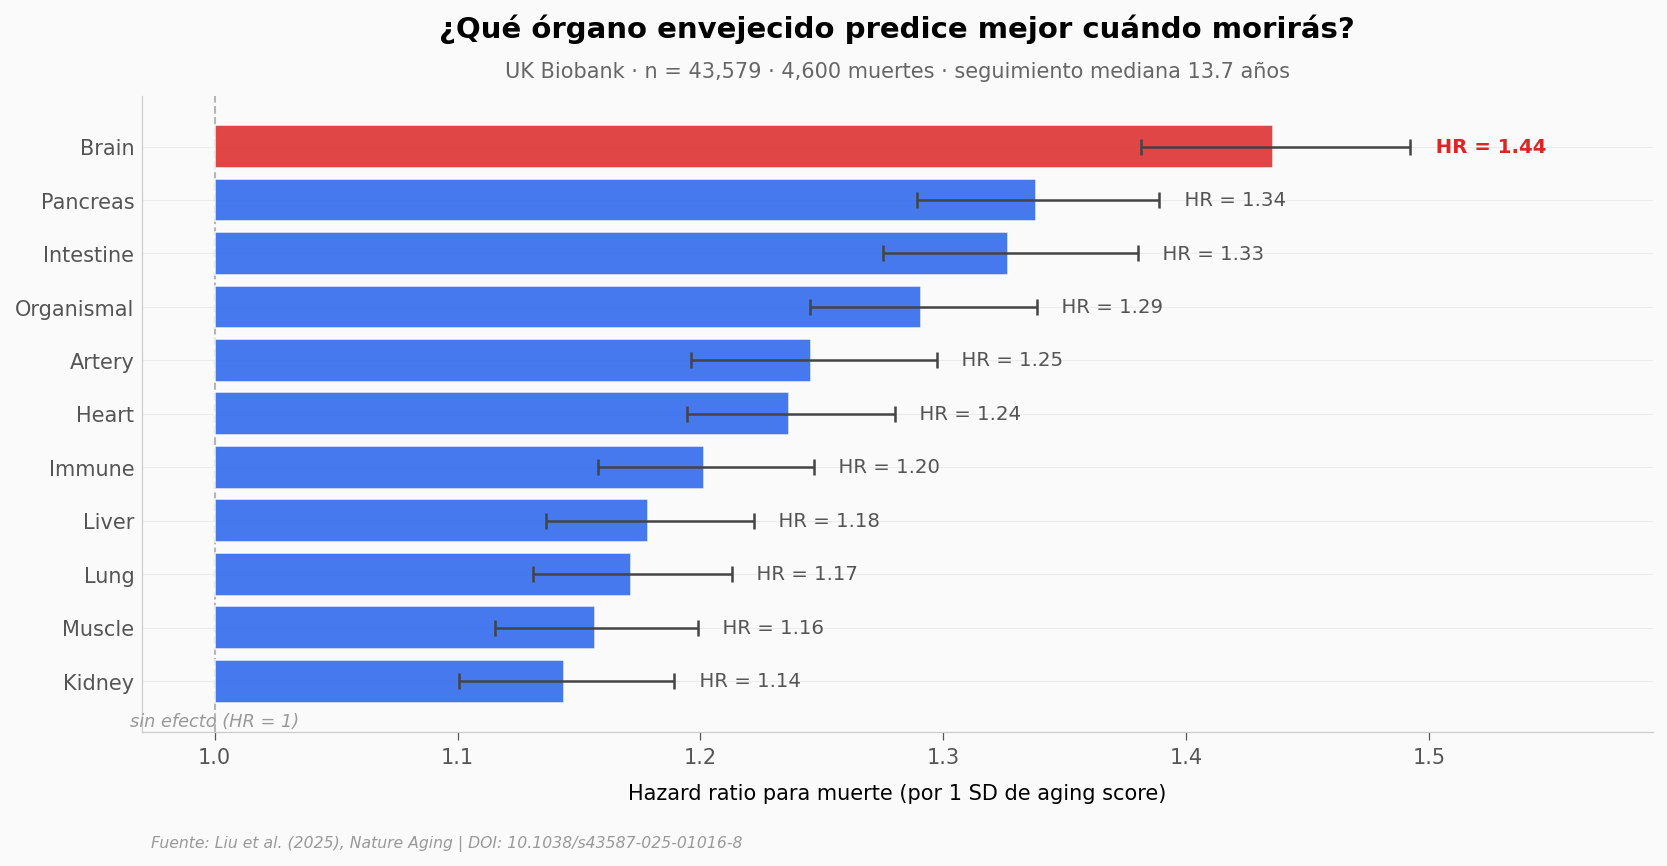

In [2]:
# Filtrar mortality (outcome='death') y ordenar por HR descendente
mortality = disease[disease.outcome == 'death'].sort_values('hr', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.5))

colores = [COLOR_ALERTA if o == ORGANO_DESTACADO else COLOR_DATOS for o in mortality.organ]
yerr = np.array([mortality.hr - mortality.ci_lower, mortality.ci_upper - mortality.hr])

bars = ax.barh(mortality.organ, mortality.hr - 1, left=1, color=colores, alpha=0.85,
               edgecolor='white', linewidth=0.8, zorder=3)
ax.errorbar(mortality.hr, mortality.organ, xerr=yerr, fmt='none',
            ecolor='#444444', capsize=4, capthick=1.2, lw=1.2, zorder=4)

# Anotación HR al final de cada barra
for i, row in mortality.iterrows():
    color = COLOR_ALERTA if row.organ == ORGANO_DESTACADO else '#555555'
    weight = 'bold' if row.organ == ORGANO_DESTACADO else 'normal'
    ax.text(row.ci_upper + 0.005, i, f'  HR = {row.hr:.2f}',
            va='center', fontsize=9.5, color=color, fontweight=weight)

ax.axvline(x=1.0, color='#999999', linewidth=1.0, linestyle='--', alpha=0.7, zorder=2)
ax.text(1.0, -0.85, 'sin efecto (HR = 1)', fontsize=8.5, color='#999999',
        ha='center', style='italic')

ax.set_xlim(0.97, mortality.ci_upper.max() + 0.10)
ax.set_xlabel('Hazard ratio para muerte (por 1 SD de aging score)', fontsize=10)
ax.set_title('¿Qué órgano envejecido predice mejor cuándo morirás?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'UK Biobank · n = 43,579 · 4,600 muertes · seguimiento mediana 13.7 años',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_mortality_ranking.png', dpi=200, bbox_inches='tight')
plt.show()

**El cerebro lidera.** Por cada SD que el reloj cerebral te marca "más viejo" que tu edad cronológica, el riesgo de muerte sube un **44 %** (HR = 1.44, IC 95 % 1.38–1.49). El páncreas es segundo (HR = 1.34), el intestino tercero (HR = 1.33).

La distancia entre el #1 y el #11 (riñón, HR = 1.14) no parece grande en una barra — pero traduce a un **factor de 3.0 ×** en el efecto sobre la mortalidad. Y el páncreas, segundo del ranking, queda **22 % por debajo** del cerebro en magnitud de efecto.

Los 11 intervalos de confianza están separados de HR = 1 — todos los relojes predicen mortalidad. Pero el cerebro lo hace con un margen claro.

## Cambiemos el outcome a demencia

Si el cerebro envejecido predice tan bien la mortalidad — ¿qué pasa cuando lo evaluamos contra demencia, donde uno esperaría que el reloj cerebral fuera el más relevante?

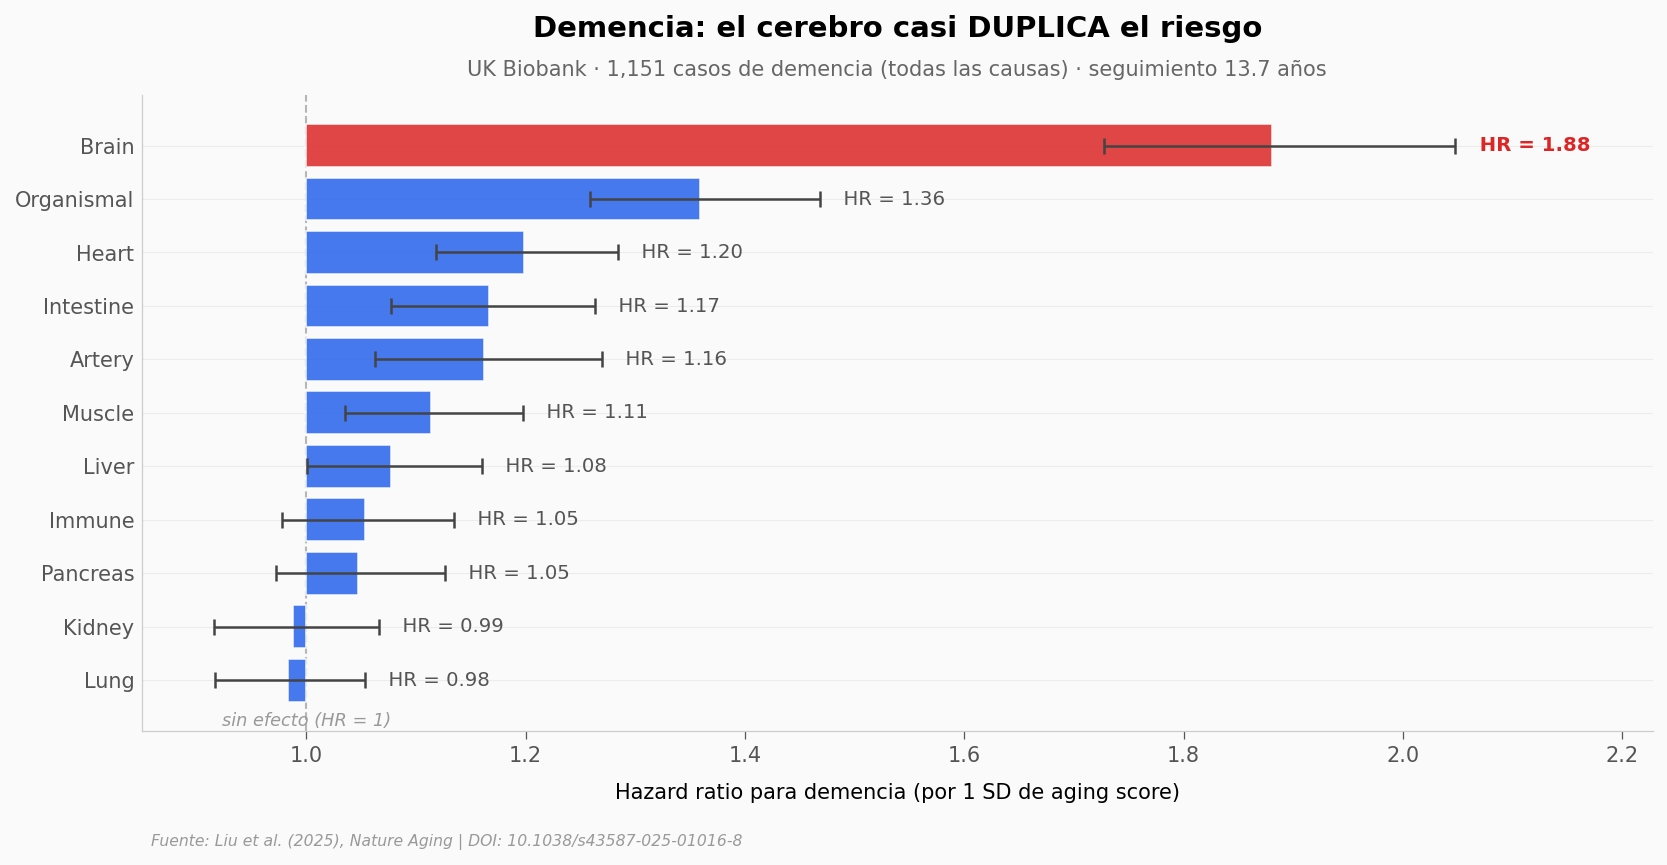

In [3]:
# Filtrar dementia (outcome='acd' = all-cause dementia)
dementia = disease[disease.outcome == 'acd'].sort_values('hr', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.5))

colores = [COLOR_ALERTA if o == ORGANO_DESTACADO else COLOR_DATOS for o in dementia.organ]
yerr = np.array([dementia.hr - dementia.ci_lower, dementia.ci_upper - dementia.hr])

ax.barh(dementia.organ, dementia.hr - 1, left=1, color=colores, alpha=0.85,
        edgecolor='white', linewidth=0.8, zorder=3)
ax.errorbar(dementia.hr, dementia.organ, xerr=yerr, fmt='none',
            ecolor='#444444', capsize=4, capthick=1.2, lw=1.2, zorder=4)

for i, row in dementia.iterrows():
    color = COLOR_ALERTA if row.organ == ORGANO_DESTACADO else '#555555'
    weight = 'bold' if row.organ == ORGANO_DESTACADO else 'normal'
    ax.text(row.ci_upper + 0.01, i, f'  HR = {row.hr:.2f}',
            va='center', fontsize=9.5, color=color, fontweight=weight)

ax.axvline(x=1.0, color='#999999', linewidth=1.0, linestyle='--', alpha=0.7, zorder=2)
ax.text(1.0, -0.85, 'sin efecto (HR = 1)', fontsize=8.5, color='#999999',
        ha='center', style='italic')

ax.set_xlim(0.85, dementia.ci_upper.max() + 0.18)
ax.set_xlabel('Hazard ratio para demencia (por 1 SD de aging score)', fontsize=10)
ax.set_title('Demencia: el cerebro casi DUPLICA el riesgo',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'UK Biobank · 1,151 casos de demencia (todas las causas) · seguimiento 13.7 años',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_dementia_ranking.png', dpi=200, bbox_inches='tight')
plt.show()

**Para mortalidad**, el cerebro queda 22 % arriba del segundo en magnitud de efecto (excess sobre HR = 1). **Para demencia**, la diferencia salta a 38 % en HR (1.88 vs 1.36 del segundo, Organismal). Pulmón (HR = 0.98), riñón (HR = 0.99) y páncreas (HR = 1.05) tienen IC 95 % que cruza 1 — sin efecto detectable sobre demencia.

Un envejecimiento órgano-específico no es un fenómeno difuso: el cerebro envejecido es lo que sube el riesgo de demencia, no "el cuerpo envejecido en general".

## ¿Cuánto se mueven los 11 relojes en sincronía?

Si el cerebro envejecido viene siempre de la mano del riñón envejecido, los 11 relojes son redundantes. Veamos la matriz de correlaciones.

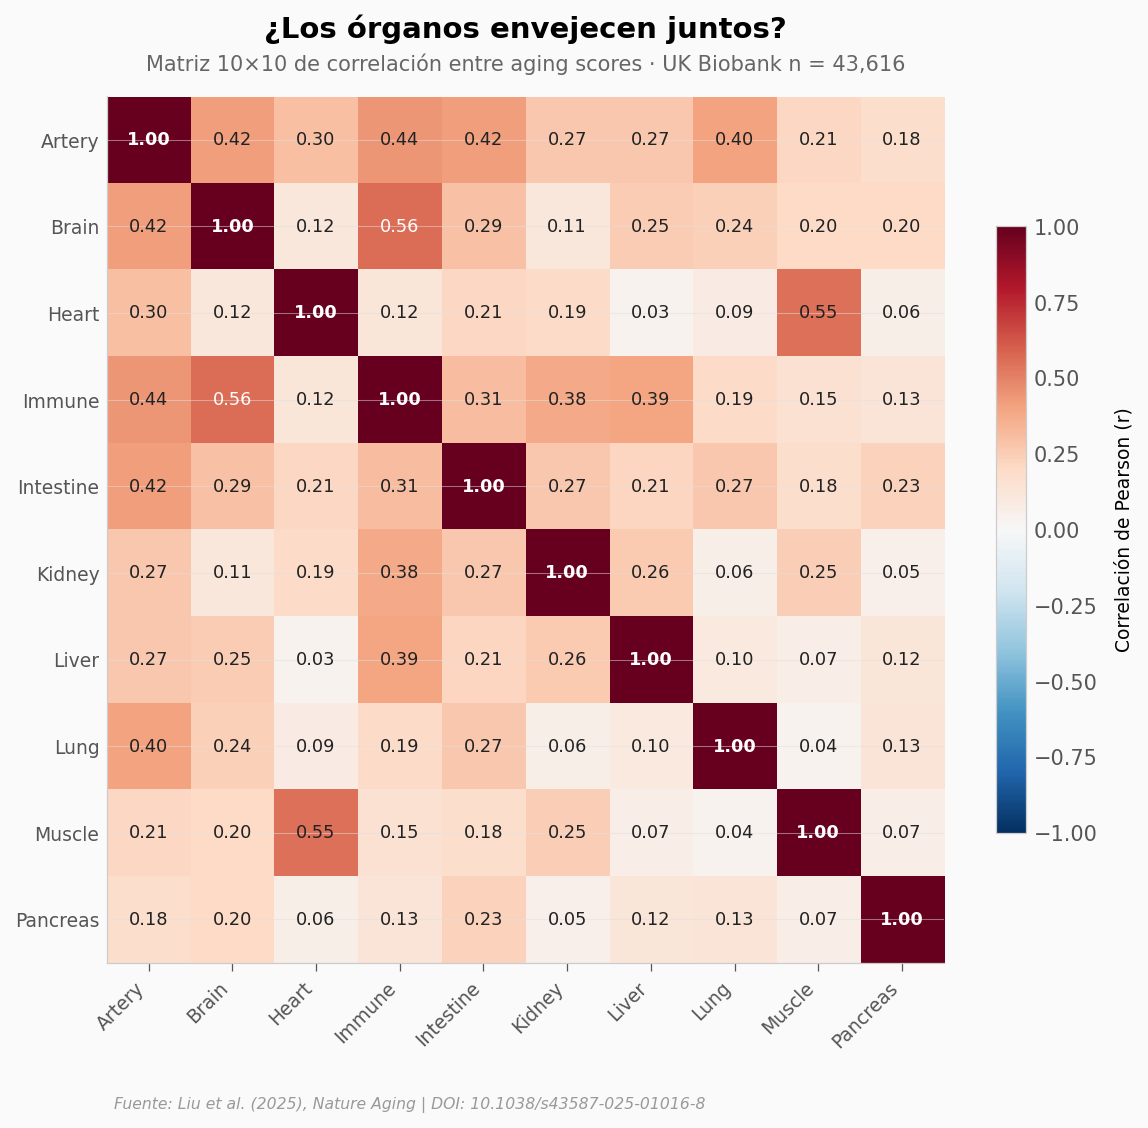

In [4]:
# Pivot a matriz 10×10
corr_matrix = corr.pivot(index='organ_x', columns='organ_y', values='r')

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Anotar cada celda con el valor de r
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.values[i, j]
        text_color = 'white' if abs(val) > 0.55 else '#222222'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8.5, color=text_color, fontweight='bold' if i == j else 'normal')

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_matrix.index, fontsize=9)

cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label('Correlación de Pearson (r)', fontsize=9)

ax.set_title('¿Los órganos envejecen juntos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Matriz 10×10 de correlación entre aging scores · UK Biobank n = 43,616',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_organ_correlations.png', dpi=200, bbox_inches='tight')
plt.show()

**Las correlaciones cruzadas son débiles a moderadas — el rango va de 0.03 a 0.56, con la mayoría de pares por debajo de 0.30.** El par más alto es cerebro–sistema inmune (r = 0.56), seguido de músculo–corazón (r = 0.55), lo que sugiere ejes inflamatorios y musculoesquelético-cardíaco compartidos. Ningún par fuera de la diagonal supera 0.60: cada órgano tiene su propia trayectoria de envejecimiento.

Esto explica por qué Brain puede ser HR = 1.88 para demencia mientras Lung es HR = 0.98 — son dimensiones del envejecimiento que el plasma logra separar.

## Una última mirada: cómo se distribuye el reloj cerebral en una población real

El *brain aging score* es un residual: 0 significa "tu cerebro coincide con tu edad cronológica". Positivo = más viejo. Negativo = más joven. ¿Qué tan común es tener un cerebro 1 SD por encima de tu edad?

> **Sobre el pico que vamos a ver en la distribución:** los modelos Olink imputan proteínas faltantes con la mediana del array antes de pasarlas al reloj. Eso genera un pico artificial centrado en la mediana del *aging score*. La gráfica lo anota explícitamente — la distribución biológica real es la cola de campana alrededor.

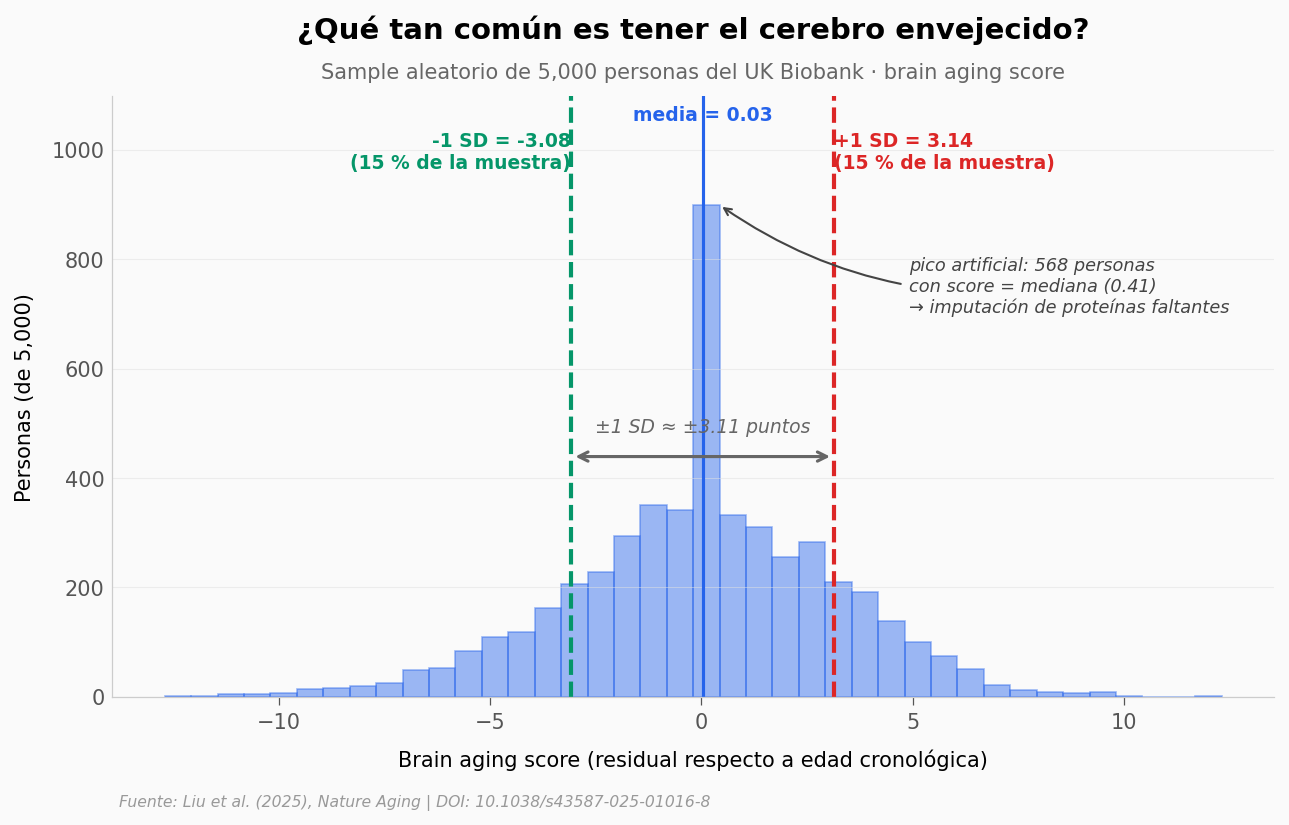


  brain aging score — media = 0.030, SD = 3.111
  14.9 % del sample tiene un cerebro >= +1 SD (3.14)
  14.9 % del sample tiene un cerebro <= -1 SD (-3.08)
  cada SD adicional → +44 % riesgo de muerte (HR = 1.44)

  NOTA: 568 personas (11.4 %) tienen el score exactamente
  igual a la mediana — marcador de imputación con la mediana cuando faltan
  proteínas Olink. No representa biología, sino una decisión analítica.


In [5]:
brain_scores = scores['Brain']

# Detectar imputación con la mediana (artefacto conocido de Olink + ML downstream)
median_brain = brain_scores.median()
n_imputed = (brain_scores.round(3) == round(median_brain, 3)).sum()
pct_imputed = n_imputed / len(brain_scores) * 100

mean_brain = brain_scores.mean()
sd_brain   = brain_scores.std(ddof=1)
umbral_pos = mean_brain + SD_REFERENCIA * sd_brain
umbral_neg = mean_brain - SD_REFERENCIA * sd_brain
pct_pos    = (brain_scores >= umbral_pos).mean() * 100
pct_neg    = (brain_scores <= umbral_neg).mean() * 100

fig, ax = plt.subplots(figsize=(10, 5.2))
n, bins, patches = ax.hist(brain_scores, bins=40, color=COLOR_DATOS, alpha=0.45,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.22
ax.set_ylim(0, y_max)

ax.axvline(x=mean_brain, color=COLOR_DATOS, linewidth=1.5, linestyle='-')
ax.axvline(x=umbral_pos, color=COLOR_ALERTA, linewidth=2.0, linestyle='--')
ax.axvline(x=umbral_neg, color=COLOR_SECUNDARIO, linewidth=2.0, linestyle='--')

ax.text(mean_brain, y_max * 0.96, f'media = {mean_brain:.2f}',
        ha='center', fontsize=9, color=COLOR_DATOS, fontweight='bold')
ax.text(umbral_pos, y_max * 0.88, f'+1 SD = {umbral_pos:.2f}\n({pct_pos:.0f} % de la muestra)',
        ha='left', fontsize=9, color=COLOR_ALERTA, fontweight='bold')
ax.text(umbral_neg, y_max * 0.88, f'-1 SD = {umbral_neg:.2f}\n({pct_neg:.0f} % de la muestra)',
        ha='right', fontsize=9, color=COLOR_SECUNDARIO, fontweight='bold')

# Anotar el spike de imputación con la mediana (artefacto, no biología)
ax.annotate(f'pico artificial: {n_imputed} personas\ncon score = mediana ({median_brain:.2f})\n→ imputación de proteínas faltantes',
            xy=(median_brain, n.max()), xytext=(median_brain + 4.5, n.max() * 0.78),
            fontsize=8.5, color='#444444', ha='left', style='italic',
            arrowprops=dict(arrowstyle='->', color='#444444', lw=1.0,
                            connectionstyle='arc3,rad=-0.2'))

# Flecha bidireccional mostrando el rango ±1SD
ax.annotate('', xy=(umbral_pos, y_max * 0.40), xytext=(umbral_neg, y_max * 0.40),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(mean_brain, y_max * 0.44, f'±1 SD ≈ ±{sd_brain:.2f} puntos',
        ha='center', fontsize=9, color='#666666', style='italic')

ax.set_xlabel('Brain aging score (residual respecto a edad cronológica)', fontsize=10)
ax.set_ylabel('Personas (de 5,000)', fontsize=10)
ax.set_title('¿Qué tan común es tener el cerebro envejecido?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Sample aleatorio de 5,000 personas del UK Biobank · brain aging score',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_brain_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\n  brain aging score — media = {mean_brain:.3f}, SD = {sd_brain:.3f}')
print(f'  {pct_pos:.1f} % del sample tiene un cerebro >= +1 SD ({umbral_pos:.2f})')
print(f'  {pct_neg:.1f} % del sample tiene un cerebro <= -1 SD ({umbral_neg:.2f})')
print(f'  cada SD adicional → +44 % riesgo de muerte (HR = 1.44)')
print()
print(f'  NOTA: {n_imputed:,} personas ({pct_imputed:.1f} %) tienen el score exactamente')
print(f'  igual a la mediana — marcador de imputación con la mediana cuando faltan')
print(f'  proteínas Olink. No representa biología, sino una decisión analítica.')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El cerebro es el órgano cuyo envejecimiento más predice la mortalidad | ✅ | HR = 1.44 (1.38–1.49), p ≈ 8.5 × 10⁻⁷⁶. El segundo (páncreas) queda 22 % por debajo en magnitud de efecto (excess sobre HR = 1) |
| Para demencia, el cerebro casi duplica el riesgo por SD | ✅ | HR = 1.88 (1.73–2.05), p ≈ 4.9 × 10⁻⁴⁸ — mientras que pulmón, riñón y páncreas tienen IC 95 % que cruza 1 (sin efecto detectable) |
| Los 11 órganos no envejecen como un todo | ✅ | Correlaciones plasmáticas entre 0.03 y 0.56; la mayoría de pares (70/90) están por debajo de 0.30, ningún par supera 0.60 |
| Los relojes funcionan en tres cohortes (UKB, CKB, NHS) | ⚠️ | El paper reporta r = 0.98 (UKB↔CKB) y r = 0.93 (UKB↔NHS) en el abstract — válido por el diseño cross-cohort. Los R² individuales por reloj sí están en `r2_cross_cohort.csv` |
| El cerebro envejecido **causa** demencia | ❌ | Diseño observacional (Cox regression). Solo soporta asociación predictiva, no causalidad |

> **Limitaciones del análisis:**
> - **Diseño observacional.** Los HRs predicen riesgo, no demuestran causalidad. Confounders no medidos pueden seguir presentes.
> - **HR por 1 SD del *aging score* residual** — no equivale a "tu cerebro envejece 44 % más rápido". Equivale a: tener un reloj cerebral 1 SD por encima de tu edad cronológica predice +44 % en el riesgo de muerte.
> - **Pico de imputación.** El histograma muestra un pico artificial centrado en la mediana del score: los modelos Olink imputan proteínas faltantes con la mediana antes de pasarlas al reloj, y el residual hereda ese pico (~11 % del sample). El cuerpo de la distribución (la campana) es la señal real.
> - **Sample de 5,000.** El histograma usa un sample aleatorio (semilla 42) para mantener el archivo manejable. La población UKB completa (n = 43,616) tiene la misma media (~0) por construcción del modelo, pero la distribución empírica completa puede tener colas más anchas.
> - **Datos crudos no descargables.** El proteoma plasmático crudo del UK Biobank requiere solicitud formal al consorcio. Este notebook reproduce el análisis downstream a partir de los *aging scores* publicados como Source Data.

## Ahora tú

1. **¿Qué órgano predice mejor el infarto de miocardio?** Filtra `disease` con `outcome == 'mi'` y ordena por HR.
2. **¿Cuál es el par de órganos con la correlación más alta — y la más baja?** Excluye la diagonal (`organ_x != organ_y`).
3. **¿Cómo cambia el ranking de mortalidad si te quedas con outcomes neurológicos vs cardiovasculares?** Compara `acd` y `parkinson` con `mi` y `stroke`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1 resuelta: ¿qué órgano predice mejor el infarto de miocardio?

mi = disease[disease.outcome == 'mi'].sort_values('hr', ascending=False).reset_index(drop=True)

print('Ranking de órganos para infarto de miocardio (HR por 1 SD):')
print('-' * 60)
for i, row in mi.iterrows():
    marker = '  <-- ' if row.organ == 'Heart' else ''
    print(f'  {i+1:2d}. {row.organ:12s}  HR = {row.hr:.2f}  ({row.ci_lower:.2f}-{row.ci_upper:.2f}){marker}')

# Pista para la pregunta 2:
#   diagonal = corr[corr.organ_x == corr.organ_y]   # las r=1
#   off_diag = corr[corr.organ_x != corr.organ_y]
#   off_diag.loc[off_diag.r.idxmax()]  # max
#   off_diag.loc[off_diag.r.idxmin()]  # min

Ranking de órganos para infarto de miocardio (HR por 1 SD):
------------------------------------------------------------
   1. Intestine     HR = 1.32  (1.24-1.41)
   2. Organismal    HR = 1.28  (1.21-1.36)
   3. Brain         HR = 1.24  (1.17-1.32)
   4. Heart         HR = 1.22  (1.15-1.30)  <-- 
   5. Artery        HR = 1.20  (1.13-1.28)
   6. Kidney        HR = 1.20  (1.13-1.28)
   7. Pancreas      HR = 1.17  (1.10-1.24)
   8. Immune        HR = 1.15  (1.08-1.22)
   9. Liver         HR = 1.14  (1.07-1.21)
  10. Lung          HR = 1.13  (1.07-1.20)
  11. Muscle        HR = 1.08  (1.02-1.15)


---

## Fuentes

**Paper**: [Organ-specific proteomic aging clocks predict disease and longevity across diverse populations](https://doi.org/10.1038/s43587-025-01016-8)  
*Nature Aging, 2025-11-26*

**Supplementary Material**: [MOESM3 — Supplementary Tables ST1–ST18 (ST4 top proteins per organ; ST5 R² cross-cohort; ST7 disease associations Cox regression)](https://static-content.springer.com/esm/art%3A10.1038%2Fs43587-025-01016-8/MediaObjects/43587_2025_1016_MOESM3_ESM.xlsx)

**Source Data**: [MOESM4 — Source Data: pc1_score por persona (UKB n=43,616 / CKB n=3,977 / NHS n=800), pc1_corr_matrix entre órganos, pc1_loading por gen](https://static-content.springer.com/esm/art%3A10.1038%2Fs43587-025-01016-8/MediaObjects/43587_2025_1016_MOESM4_ESM.xlsx)

**Código del paper**: [Organ-PAC — Proteomic organ-specific aging clock across diverse populations (analysis code)](https://github.com/41way5/Organ-PAC)

*15 afirmaciones del notebook verificadas contra estas fuentes.*

---

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · **Licencia:** CC BY 4.0 (notebook), licencias originales para los datos del paper.